# Self-Supervised Learning

**Self-Supervised Learning (SSL)** is a Deep Learning technique that leverages **pretext tasks** to pre-train a model before it is applied to a main (downstream) task. This approach is particularly effective when the **number of labeled samples** available for training is limited.

In this notebook, you will complete **two exercises** covering two distinct self-supervised approaches:



1.   **Rotation-Based Pretext Task:** You will perform **image classification** on the MNIST dataset (handwritten digits). Before training the model on limited labeled data, you will pre-train it on a **rotation task.** In this stage, images are randomly rotated by 0, 90, 180, or 270 degrees, and the model must predict the specific angle of rotation. This process forces the model **to learn relevant features** (such as shapes and orientations) before it is fine-tuned for the main digit classification task.
2.   **Contrastive Learning Pretext Task:** You will perform **image classification** on the CIFAR-10 dataset (containing 10 classes, such as airplanes, birds, and cats). For this exercise, you will pre-train the model using a Contrastive Learning approach (specifically SimCLR). The model will learn to map two different augmented versions of the same image **close together** in the feature space, while simultaneously mapping different images **far apart.** Through this process, the model automatically learns to extract high-level features necessary for robust image recognition across all classes.



## Rotation Pretext Task

### Imports and Utilities

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import copy
import numpy as np
import random

In [2]:
# The MNIST dataset contains digits from 0 to 9. Since the pretext task is rotation-based, it makes no
# sense to rotate 6 and 9: this would just confuse the model.
# Therefore, the rotation pretext task will be applied using just 0, 1, 2, 3, 4, 5, 7, 8 digits.
def get_filtered_mnist():
    # Define transformation
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])

    # Load the dataset
    full_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

    # Take every sample except 6 and 9 classes
    indices = [i for i, (_, label) in enumerate(full_train) if label not in [6, 9]]

    # Return the subset
    return Subset(full_train, indices)

### Model Definition

In [3]:
# Define the model for classification (a simple CNN).
# Note: this model is the one to be applied to the main classification task, which involves 10 classes.
# For this reason num_classes is set to 10 by default.
# This value will be changed before the pre-text task, which is a classification task in which classes are just four, representing rotation angles: 0, 90, 180, 270.
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # Define the feature extractor (encoder): conv layer (1 input channel for grayscale, 32 output channels, kernel size = 3, stride = 1) -> relu ->
        # -> conv layer (64 output channels) -> relu -> max pooling -> flattening (use nn.Flatten()) -> Linear (128 output neurons) -> relu
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Flatten(),
            nn.Linear(64 * 12 * 12, 128),
            nn.ReLU()
        )

        # Define the final fc layer for the final prediction
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):

        features = self.encoder(x)
        return self.fc(features)

### Custom Dataset (for Rotation Task)

In [4]:
# This custom dataset should return a collection of training samples for the rotation pre-text task.
# For each image, we will randomly rotate it, and we will return the rotated image and the rotation angle as ground truth label
class RotationDataset(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
        self.angles = [0, 90, 180, 270]

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        # Extract the image at index "index" and discard original label
        img, _ = self.dataset[index]

        # Define integer label representing rotation angle
        label = random.randint(0, 3)   # 0 for 0 degrees, 1 for 90 degrees, 2 for 180 degrees, 3 for 270 degrees

        # Return randomly rotated image, AND the corresponding label
        # To rotate the image, use TF.rotate, taking as arguments the image and the angle corresponding to label
        return TF.rotate(img, self.angles[label]), label

### Training and Evaluation

In [5]:
def train_model(model, loader, epochs, lr):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for _ in range(epochs):
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), lbls)
            loss.backward()
            optimizer.step()

# Evaluation function
def evaluate(model, loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            correct += (model(imgs).argmax(dim=1) == lbls).sum().item()
    return correct / len(loader.dataset)

In [6]:
# Initialize the device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [7]:
# This function creates two versions of the same model. The first is pre-trained on the rotation task to learn basic image features.
# Then, both models are trained five times each on the final classification task using an increasing number of labels.
# You should observe that the pre-trained model performs better, especially when training data is scarce.
# As more labeled samples become available, the gap between the two models will likely shrink,
# because the model trained from scratch finally has enough information to catch up.
def run_multi_trial_experiment():
    # Load the filtered dataset (filtered = missing 6 and 9)
    mnist_filtered = get_filtered_mnist()

    # Pre-train the SSL model once on the unlabeled data
    print("Step 1: Training Pretext Task (Rotation)...")
    pretext_dataset = RotationDataset(mnist_filtered)
    pretext_loader = DataLoader(pretext_dataset, batch_size=64, shuffle=True)
    base_ssl_model = SimpleCNN(num_classes=4).to(device)

    train_model(base_ssl_model, pretext_loader, epochs=10, lr=0.001)

    sample_sizes = [10, 25, 50, 100, 200] # increasing training labels
    num_trials = 5

    results = { "scratch": {n: [] for n in sample_sizes}, "ssl": {n: [] for n in sample_sizes} }

    # Fixed Large Validation Set
    # The Subset class returns a partition of the original dataset given some indices
    val_loader = DataLoader(Subset(mnist_filtered, range(2000, 4000)), batch_size=128)

    for n in sample_sizes:
        print(f"\n--- Testing N={n} labeled samples ---")
        for trial in range(num_trials):
            # Randomly pick n samples for this trial
            indices = torch.randperm(len(mnist_filtered))[:n]
            train_loader = DataLoader(Subset(mnist_filtered, indices), batch_size=min(n, 16), shuffle=True)

            # Scratch Trial
            m_scratch = SimpleCNN(num_classes=10).to(device)
            train_model(m_scratch, train_loader, epochs=20, lr=0.001)

            results["scratch"][n].append(evaluate(m_scratch, val_loader))

            # SSL Trial
            m_ssl = copy.deepcopy(base_ssl_model)

            # Note: the final fc layer of m_ssl is suitable for 4 classes, not 10.
            m_ssl.fc = nn.Linear(128, 10).to(device)

            train_model(m_ssl, train_loader, epochs=20, lr=0.0005)
            results["ssl"][n].append(evaluate(m_ssl, val_loader))

            print(f" Trial {trial+1}/{num_trials} complete.")

    # Calculate averages and plots
    scratch_means = [np.mean(results["scratch"][n]) for n in sample_sizes]
    ssl_means = [np.mean(results["ssl"][n]) for n in sample_sizes]

    plt.figure(figsize=(10, 6))
    plt.plot(sample_sizes, scratch_means, 'o-', label='From Scratch (Avg)', color='crimson', linewidth=2)
    plt.plot(sample_sizes, ssl_means, 's-', label='SSL Pre-trained (Avg)', color='seagreen', linewidth=2)

    plt.title(f"SSL vs Scratch: Average of {num_trials} Trials", fontsize=14)
    plt.xlabel("Number of Labeled Samples", fontsize=12)
    plt.ylabel("Validation Accuracy", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

Step 1: Training Pretext Task (Rotation)...

--- Testing N=10 labeled samples ---
 Trial 1/5 complete.
 Trial 2/5 complete.
 Trial 3/5 complete.
 Trial 4/5 complete.
 Trial 5/5 complete.

--- Testing N=25 labeled samples ---
 Trial 1/5 complete.
 Trial 2/5 complete.
 Trial 3/5 complete.
 Trial 4/5 complete.
 Trial 5/5 complete.

--- Testing N=50 labeled samples ---
 Trial 1/5 complete.
 Trial 2/5 complete.
 Trial 3/5 complete.
 Trial 4/5 complete.
 Trial 5/5 complete.

--- Testing N=100 labeled samples ---
 Trial 1/5 complete.
 Trial 2/5 complete.
 Trial 3/5 complete.
 Trial 4/5 complete.
 Trial 5/5 complete.

--- Testing N=200 labeled samples ---
 Trial 1/5 complete.
 Trial 2/5 complete.
 Trial 3/5 complete.
 Trial 4/5 complete.
 Trial 5/5 complete.


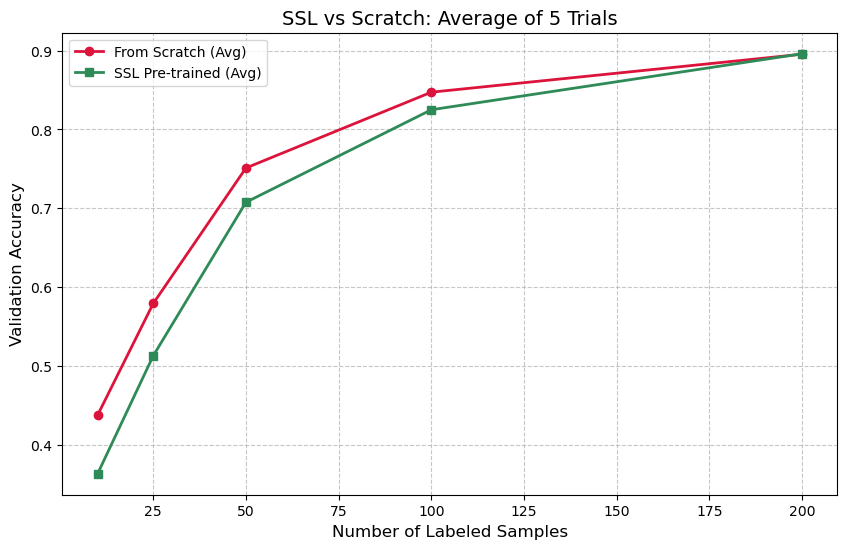

In [8]:
run_multi_trial_experiment()

## Contrastive Learning

### Imports

In [9]:
import os
import glob
import copy
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset

from torchvision import models, datasets, transforms
import torchvision.transforms.functional as TF

In [10]:
# Initialize the device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

### Contrastive Learning Logic

#### Augmentations

In [11]:
# This class takes an image x and returns two different augmented versions of x
class SimCLRTransform:
    def __init__(self, size=32):
        self.transform = transforms.Compose([
            transforms.RandomResizedCrop(size=size),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomApply([transforms.ColorJitter(0.8, 0.8, 0.8, 0.2)], p=0.8),
            transforms.RandomGrayscale(p=0.2),
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
        ])

    def __call__(self, x):
        # We return two different augmented versions of the same image 'x'
        return self.transform(x), self.transform(x)

#### Model

In [12]:
class SimCLR(nn.Module):
    def __init__(self):
        super().__init__()
        # As features extractor we use an already existing architecture, called resnet18 (because it has 18 trainable layers)
        # Weights are not initialized, as we want to initialize them using Contrastive Learning
        self.backbone = models.resnet18(weights=None)
        dim_mlp = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()    # Neutering the final classification layer, as we just want to train a feature extractor
        self.projector = nn.Sequential(nn.Linear(dim_mlp, dim_mlp), nn.ReLU(), nn.Linear(dim_mlp, 128))

    def forward(self, x):
        h = self.backbone(x)
        return self.projector(h)

#### Contrastive Loss

The **Contrastive Loss** is the core of Contrastive Learning: it teaches the model how to recognize **two different instances of the same class** without telling it which class it is.

Given a training batch, we create a positive pair and several negative pairs.


*   **Positive Pair:** the two instances of the same image.
*   **Negative Pair:** every other image in the current batch wrt the anchor image.

Then, through matrix multiplication, a **grid of scores** is created.


*   The **diagonal** of this matrix represents the similarity between an image and its own augmented twin (the positive pairs).
*   Everything **off the diagonal** represents the similarity between an image and a completely different image (the negative pairs).

We use CrossEntropyLoss to pick **1 "twin" out of 255 "strangers"** (assuming a batch size of 256).









In [13]:
# Computes the Symmetric Contrastive Loss (NT-Xent) between two augmented views.

# This function encourages the model to maximize the similarity between 'z1' and 'z2'
# (positive pairs) while minimizing their similarity with all other samples in the
# batch (negative pairs). Using a symmetric approach ensures the model learns
# consistent representations regardless of which view is used as the anchor.
def contrastive_loss(z1, z2, temperature=0.1):

    # Note: since dataloaders process data in batches, z1 and z2 are actually matrices
    # The dimension is [BatchSize, OutputDim], where Batchsize=256 and OutputDim=128 (the number of output neurons used in the final fc of the model)
    # Each row of z1 is a 128-d fingerprint of an image, and the corresponding row of z2 is the fingerprint of the other view of the same image

    # Normalize the vectors
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    # Calculate logits (how similar each image is to every other image)
    # The result is a [256, 256] matrix, in which each cell (i,j) represents the similarity between the i-th row of z1 and the j-th row of v2
    # The elements on the diagonal are the similarities between the two views of the same image
    # Similarity should be 1 between views of the same image, and -1 (or low), between different images
    # Temperature acts like a magnifying glass: it stretches the similarities, otherwise these would be too flat for cross entropy
    logits_1_to_2 =z1 @ z2.T / temperature
    logits_2_to_1 =z2 @ z1.T / temperature

    # Targets: Each image i in z1 should match image i in z2
    # This is just [0, 1, 2, ..., N-1]
    labels = torch.arange(z1.size(0)).to(z1.device)

    # Symmetric Cross Entropy
    loss_a = F.cross_entropy(logits_1_to_2, labels)
    loss_b = F.cross_entropy(logits_2_to_1, labels)

    return (loss_a + loss_b) / 2

#### Training on Pretext Task

In [14]:
# Define the classes we want to keep (indices 0 through 4)
# 0: airplane, 1: automobile, 2: bird, 3: cat, 4: deer
target_classes = [0, 1, 2, 3, 4]
images_per_class = 2000

# Load the full dataset without any transform first to find indices
full_train_ds = datasets.CIFAR10(root='./data', train=True, download=True)
all_labels = np.array(full_train_ds.targets)

# Filter indices
subset_indices = []
for cls in target_classes:
    # Get all indices where label == cls
    cls_indices = np.where(all_labels == cls)[0]
    # Take only the first 2000
    selected_indices = cls_indices[:images_per_class]
    subset_indices.extend(selected_indices)

# Create the Final Pretext Dataset with SimCLRTransform
# We re-load with the transform and then wrap in a Subset
transformed_ds = datasets.CIFAR10(
    root='./data',
    train=True,
    download=False,
    transform=SimCLRTransform(size=32)
)

pretext_dataset = Subset(transformed_ds, subset_indices)

# Create the Loader
pretext_loader = DataLoader(pretext_dataset, batch_size=256, shuffle=True)

print(f"Total images for Pretext Task: {len(pretext_dataset)}")

100%|██████████| 170498071/170498071 [00:40<00:00, 4170516.89it/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Total images for Pretext Task: 10000


In [15]:
# Instantiate the model and move it to right device
model = SimCLR().to(device)

# Define the optimizer. Use lr=1e-3
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(20):
    for (v1, v2), _ in pretext_loader:
        # Note: v1 and v2 are two augmented views of the same image
        v1, v2 = v1.to(device), v2.to(device)

        optimizer.zero_grad()

        loss = contrastive_loss(model(v1), model(v2))

        loss.backward()
        optimizer.step()
    print(f"Pretext Epoch {epoch} Loss: {loss.item():.4f}")

Pretext Epoch 0 Loss: 2.5194
Pretext Epoch 1 Loss: 2.8023
Pretext Epoch 2 Loss: 2.6918
Pretext Epoch 3 Loss: 1.9631
Pretext Epoch 4 Loss: 2.2898
Pretext Epoch 5 Loss: 2.7625
Pretext Epoch 6 Loss: 2.0334
Pretext Epoch 7 Loss: 2.2709
Pretext Epoch 8 Loss: 1.9682
Pretext Epoch 9 Loss: 2.2372
Pretext Epoch 10 Loss: 1.6034
Pretext Epoch 11 Loss: 2.7416
Pretext Epoch 12 Loss: 2.0911
Pretext Epoch 13 Loss: 2.8192
Pretext Epoch 14 Loss: 2.3044
Pretext Epoch 15 Loss: 1.8066
Pretext Epoch 16 Loss: 1.9559
Pretext Epoch 17 Loss: 2.0753
Pretext Epoch 18 Loss: 2.0546
Pretext Epoch 19 Loss: 1.9980


### Main Classification Task

In [16]:
# Create the SSL-boosted model
model_ssl = copy.deepcopy(model.backbone)

model_ssl.fc = nn.Linear(512, 5)
model_ssl = model_ssl.to(device)

# Create the scratch model
model_scratch = models.resnet18(weights=None)

# Adjusting the first layers to match the CIFAR architecture used in Pretext
model_scratch.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model_scratch.maxpool = nn.Identity()
model_scratch.fc = nn.Linear(512, 5)
model_scratch = model_scratch.to(device)

In [17]:
# Standard transform for testing
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

In [18]:
# Load full CIFAR-10
full_train = datasets.CIFAR10(root='./data', train=True, download=True, transform=eval_transform)
full_test = datasets.CIFAR10(root='./data', train=False, download=True, transform=eval_transform)

Files already downloaded and verified
Files already downloaded and verified


In [19]:
test_indices = [i for i, label in enumerate(full_test.targets) if label < 5]
test_loader = DataLoader(Subset(full_test, test_indices), batch_size=100)

In [20]:
# Helper functions to keep the loop clean
def train_simple(m, loader, epochs, lr=1e-3):
    m.train()
    opt = optim.Adam(m.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            crit(m(x), y).backward()
            opt.step()

def evaluate_simple(m, loader):
    m.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            correct += (m(x).argmax(1) == y).sum().item()
            total += y.size(0)
    return 100 * correct / total

In [21]:
def run_cifar_comparison(m_scratch, m_ssl):
    # Define sample sizes (total labels) and trials
    # Since we have 5 classes, n=10 means only 2 images per class!
    sample_sizes = [10, 25, 50, 100, 200]
    num_trials = 5

    # Store results for plotting
    results = {
        "scratch": {n: [] for n in sample_sizes},
        "ssl": {n: [] for n in sample_sizes}
    }

    print("Starting Multi-Trial Experiment...")

    for n in sample_sizes:
        print(f"\n--- Testing N={n} total labeled samples ---")

        for trial in range(num_trials):
            # Create a fresh tiny training set for this trial
            # We use (n // 5) images per class to keep it balanced
            n_per_class = max(1, n // 5)
            indices = []
            labels_array = np.array(full_train.targets)
            for cls_idx in range(5):
                cls_indices = np.where(labels_array == cls_idx)[0]
                # Randomly sample indices for this trial
                selected = np.random.choice(cls_indices, n_per_class, replace=False)
                indices.extend(selected)

            # Define the train loader
            trial_train_loader = DataLoader(
                Subset(full_train, indices),
                batch_size=min(n, 16),
                shuffle=True
            )

            epochs = 25

            train_simple(m_scratch, trial_train_loader, epochs=epochs, lr=1e-3)
            acc_s = evaluate_simple(m_scratch, test_loader)
            results["scratch"][n].append(acc_s)

            # Train SimCLR SSL model
            train_simple(m_ssl, trial_train_loader, epochs=epochs, lr=5e-4)
            acc_l = evaluate_simple(m_ssl, test_loader)
            results["ssl"][n].append(acc_l)

            print(f" Trial {trial+1}/{num_trials} | Scratch: {acc_s:.1f}% | SSL: {acc_l:.1f}%")

    # Calculate averages and plots
    scratch_means = [np.mean(results["scratch"][n]) for n in sample_sizes]
    ssl_means = [np.mean(results["ssl"][n]) for n in sample_sizes]

    # Calculate Standard Deviation for error bars
    scratch_stds = [np.std(results["scratch"][n]) for n in sample_sizes]
    ssl_stds = [np.std(results["ssl"][n]) for n in sample_sizes]

    plt.figure(figsize=(10, 6))
    plt.errorbar(sample_sizes, scratch_means, yerr=scratch_stds, fmt='o-', label='From Scratch', color='crimson', capsize=5)
    plt.errorbar(sample_sizes, ssl_means, yerr=ssl_stds, fmt='s-', label='SimCLR Pre-trained', color='seagreen', capsize=5)

    plt.title(f"SimCLR vs Scratch: Average of {num_trials} Trials (CIFAR-10)", fontsize=14)
    plt.xlabel("Total Labeled Samples (5 Classes)", fontsize=12)
    plt.ylabel("Test Accuracy (%)", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

Starting Multi-Trial Experiment...

--- Testing N=10 total labeled samples ---
 Trial 1/5 | Scratch: 32.9% | SSL: 35.2%
 Trial 2/5 | Scratch: 22.6% | SSL: 33.6%
 Trial 3/5 | Scratch: 25.4% | SSL: 37.8%
 Trial 4/5 | Scratch: 30.6% | SSL: 31.1%
 Trial 5/5 | Scratch: 28.5% | SSL: 33.4%

--- Testing N=25 total labeled samples ---
 Trial 1/5 | Scratch: 36.5% | SSL: 41.4%
 Trial 2/5 | Scratch: 30.3% | SSL: 35.2%
 Trial 3/5 | Scratch: 33.6% | SSL: 44.6%
 Trial 4/5 | Scratch: 37.1% | SSL: 43.5%
 Trial 5/5 | Scratch: 43.7% | SSL: 41.4%

--- Testing N=50 total labeled samples ---
 Trial 1/5 | Scratch: 36.1% | SSL: 40.2%
 Trial 2/5 | Scratch: 41.1% | SSL: 34.5%
 Trial 3/5 | Scratch: 44.3% | SSL: 41.3%
 Trial 4/5 | Scratch: 38.0% | SSL: 42.6%
 Trial 5/5 | Scratch: 41.4% | SSL: 37.1%

--- Testing N=100 total labeled samples ---
 Trial 1/5 | Scratch: 43.3% | SSL: 44.7%
 Trial 2/5 | Scratch: 47.4% | SSL: 44.8%
 Trial 3/5 | Scratch: 48.9% | SSL: 43.1%
 Trial 4/5 | Scratch: 47.2% | SSL: 46.0%
 Trial 5/

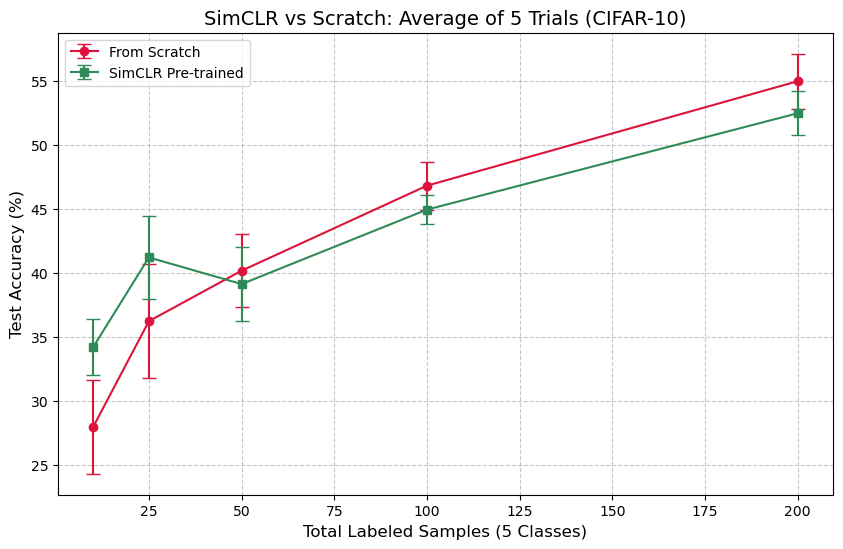

In [22]:
run_cifar_comparison(model_scratch, model_ssl)

### Analisi critica del risultato finale

Nel grafico finale si osserva un pattern plausibile: per **N molto piccoli (10-25)** il modello con pre-training contrastivo tende a essere migliore, mentre aumentando le etichette (**N >= 50**) il modello from scratch recupera e in alcuni casi supera SSL.

Questo andamento e coerente con l'idea generale di Self-Supervised Learning: il pre-training aiuta soprattutto nel regime a bassa disponibilita di label. Tuttavia, in questa implementazione il risultato va interpretato con cautela per tre motivi sperimentali.

1. **Trial non indipendenti (fattore piu critico)**
   Nel ciclo multi-trial i modelli vengono riutilizzati senza reinizializzazione a ogni trial. In questo modo le performance accumulano training precedente e le medie non rappresentano veri esperimenti indipendenti. Questo puo alterare sia il punto di crossover sia l'ampiezza del vantaggio/svantaggio tra SSL e scratch.

2. **Asimmetria architetturale tra i due rami**
   Il ramo scratch usa uno stem adattato a CIFAR-10 (conv3x3, stride 1, niente maxpool), mentre il backbone SSL deriva dal ResNet18 standard usato nel pretext. Quindi il confronto non isola soltanto l'effetto del pre-training, ma anche differenze architetturali.

3. **Pre-training contrastivo breve**
   Con sole 20 epoche di pretext learning, la qualita delle rappresentazioni puo essere ancora limitata. In pratica SSL mostra utilita nel regime ultra-low-label, ma potrebbe non esprimere pienamente il proprio potenziale quando il downstream diventa piu ricco di dati.

### Conclusione (versione robusta)

Il risultato e **coerente come tendenza qualitativa** (SSL utile con pochissime etichette), ma **non ancora conclusivo in senso sperimentale forte**. Per una valutazione affidabile servono: trial indipendenti (reset/deepcopy per trial), architettura allineata tra SSL e scratch, e una procedura di pre-training piu estesa. Con questi accorgimenti il confronto misurerebbe in modo piu pulito il reale contributo del pre-training contrastivo.